# Project second part 

### This jupyter will be organized in 3 parts :
- Data cleansing according to the mail instructions
- Data cleansing/modifications according to the article [here](5132133.pdf)
- Visualization of five plots
   

## Data cleansing and missing values

### Imports and load dataset

In [94]:
# Load data from shots_logs.csv file 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Troubleshooting with library versions
"""
print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
"""
DATA_PATH = "shot_logs.csv"
nba_shots = pd.read_csv(DATA_PATH, encoding='utf-8')
print(nba_shots.head(5))

    GAME_ID                   MATCHUP LOCATION  W  FINAL_MARGIN  SHOT_NUMBER  \
0  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            1   
1  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            2   
2  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            3   
3  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            4   
4  21400899  MAR 04, 2015 - CHA @ BKN        A  W            24            5   

   PERIOD GAME_CLOCK  SHOT_CLOCK  DRIBBLES  ...  SHOT_DIST  PTS_TYPE  \
0       1       1:09        10.8         2  ...        7.7         2   
1       1       0:14         3.4         0  ...       28.2         3   
2       1       0:00         NaN         3  ...       10.1         2   
3       2      11:47        10.3         2  ...       17.2         2   
4       2      10:34        10.9         2  ...        3.7         2   

   SHOT_RESULT   CLOSEST_DEFENDER CLOSEST_DEFENDER_PLAYER_ID  CLOSE_DEF_DIST  \
0     

### Find missing values
There are no constant feature in the dataset so we will focus on finding missing values and either fill them or remove the feature

In [95]:
#There are no constant feature in the dataset so we will focus on finding missing values
print("="*35)
print("before filling missing values")
print("="*35)

miss_percent = nba_shots.isnull().mean() * 100
miss_percent_filtered = miss_percent[miss_percent > 0].sort_values(ascending=False)
print(miss_percent_filtered)

# As we can see only 4.3 precent of the shot clock is missing 
# The only feature I'm missing is “shot_clock” at 4.3%. I think I'll fill it in with an average per quarter. 
# My assumption that a shot taken in the 4th quarter can have more impact on the outcome of the game than a shot taken in the 1st quarter,
# so i will compute a median per period 

nba_shots['SHOT_CLOCK'] = nba_shots.groupby('PERIOD')['SHOT_CLOCK'].transform(
    lambda x: x.fillna(x.mean())
)

# Here, this is just to ensure that the missing data in the specified column has been filled in.
print("="*35)
print("after filling missing values")
print("="*35)

miss_percent_2 = nba_shots.isnull().mean() * 100
miss_percent_2_filtered = miss_percent_2[miss_percent_2 > 0]
if len(miss_percent_2_filtered) == 0:
    print("no missing values")
else :
    print(miss_percent_2_filtered)

#Code location 0 for home game and 1 eles
if 'LOCATION_H' in nba_shots.columns:
    nba_shots['LOCATION'] = nba_shots['LOCATION_H'].apply(lambda x: 'H' if x == 1 else 'A')
if 'W_W' in nba_shots.columns:
    nba_shots['W'] = nba_shots['W_W'].apply(lambda x: 'W' if x == 1 else 'L')    


before filling missing values
SHOT_CLOCK    4.346876
dtype: float64
after filling missing values
no missing values


### Data cleansing/modifications according to the article
According to the article i did not  binned continuous data into 4 categories because it says  "binning did not seem to make a noticeable difference in my results with Naive Bayes"

In [96]:
import datetime
from sklearn.model_selection import train_test_split
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

#Save FGM column for the train and test split because this column will be removed trough dataset modifications 
y = nba_shots['FGM']

#Drop the FGM and PTS column to prevent data leakage because they are perfect predictors
DROP_COLUMNS = {'FGM','PTS'}
nba_shots = nba_shots.drop(columns=DROP_COLUMNS, errors='ignore')

#transform GAME_CLOCK from string '%M:%S' to '%S'
def time_to_seconds(time_str):
    time_obj = datetime.strptime(time_str, '%M:%S')
    seconds = (time_obj - datetime(1900, 1, 1)).total_seconds()
    return int(seconds)

nba_shots['GAME_CLOCK'] = nba_shots['GAME_CLOCK'].apply(time_to_seconds)

#Create column total date time 
# Formule: (PERIOD - 1) * 720 + (720 - GAME_CLOCK)
# 720 s = 12 min = 1 nba quarter
nba_shots['TOTAL_GAME_TIME'] = ((nba_shots['PERIOD'] - 1) * 720 + (720 - nba_shots['GAME_CLOCK']))

#remove categorical variables that have more than two categories
categorical_to_drop = ['GAME_ID', 'MATCHUP', 'CLOSEST_DEFENDER','CLOSEST_DEFENDER_PLAYER_ID','player_name','player_id']
nba_shots.drop(categorical_to_drop, axis=1, inplace=True)

#split train and test data to 90/10
X_train, X_test, y_train, y_test = train_test_split(nba_shots, y, test_size=0.1,random_state=42)


numerical_cols = nba_shots.select_dtypes(include=['float64', 'int64']).columns.tolist()
scaler = MinMaxScaler()
scaler.fit(X_train[numerical_cols])

#transform X_train
X_train[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("="*30)
print("X_train after min max scaling")
print("="*30)
print(X_train.head(5))

print("\n" + "="*30)
print("Min:", X_train['CLOSE_DEF_DIST'].min())
print("Max:", X_train['CLOSE_DEF_DIST'].max())
print("="*30)

X_train after min max scaling
      LOCATION  W  FINAL_MARGIN  SHOT_NUMBER    PERIOD  GAME_CLOCK  \
3349         H  W      0.518868     0.459459  0.500000    0.347222   
86           A  W      0.537736     0.162162  0.333333    0.444444   
79784        A  W      0.556604     0.000000  0.166667    0.933333   
17805        H  W      0.575472     0.027027  0.000000    0.563889   
71554        A  L      0.424528     0.027027  0.500000    0.584722   

       SHOT_CLOCK  DRIBBLES  TOUCH_TIME  SHOT_DIST  PTS_TYPE SHOT_RESULT  \
3349     0.395833  0.000000    0.872679   0.516060       1.0        made   
86       0.512500  0.064516    0.880637   0.072805       0.0        made   
79784    0.616667  0.000000    0.872679   0.402570       0.0      missed   
17805    0.879167  0.000000    0.872149   0.531049       1.0        made   
71554    0.708333  0.000000    0.873210   0.541756       1.0        made   

       CLOSE_DEF_DIST  TOTAL_GAME_TIME  
3349         0.099624         0.521851  
86        

# NBA Shot Analysis
### Figure 1: Shot Distance vs. Defender Proximity

Scatter plot correlating shot distance with the distance of the closest defender.
It reveals that high-percentage shots are near the rim or when defenders are not close to the shooter.

### Figure 2: Accuracy by Distance (5ft Slices)

Categorical bar chart made of 5-foot distance intervals.
As we can see, the first 5 ft have a very high efficiency, and the further we go, the lower the efficiency is.
However, we can see that the last slice has a slightly better accuracy. This can be explained by the fact that these are considered bad shots, so they are most likely not being contested, and only a few shots are taken from this distance.

### Figure 3: Shot Accuracy Trend by Quarter

Line plot showing how the mean accuracy evolves through the four periods (quarters) of a game.
We can see that the global accuracy drops as the game continues. This can be due to fatigue or pressure during the match.

### Figure 4: Precision at Home vs. Away

Bar chart comparing the average FGM percentage based on the game location (Home/Away).
From this graphic, we cannot conclude that players are less efficient when they are not playing at home.
Since, in the data, games stop on March 4, I can only assume that playoff games are not included in this dataset. Therefore, we cannot make the same graph to see if there is a location advantage during important games.

### Figure 5: Shot Distance Distribution

A histogram with a density curve of the volume of shots and the distance, marked with the 3-point line.
This distribution allows us to see that NBA teams value 3pt shots a lot and are completely abandoning 2pt shots outside the paint.

/tmp/ipykernel_548367/3112327237.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)


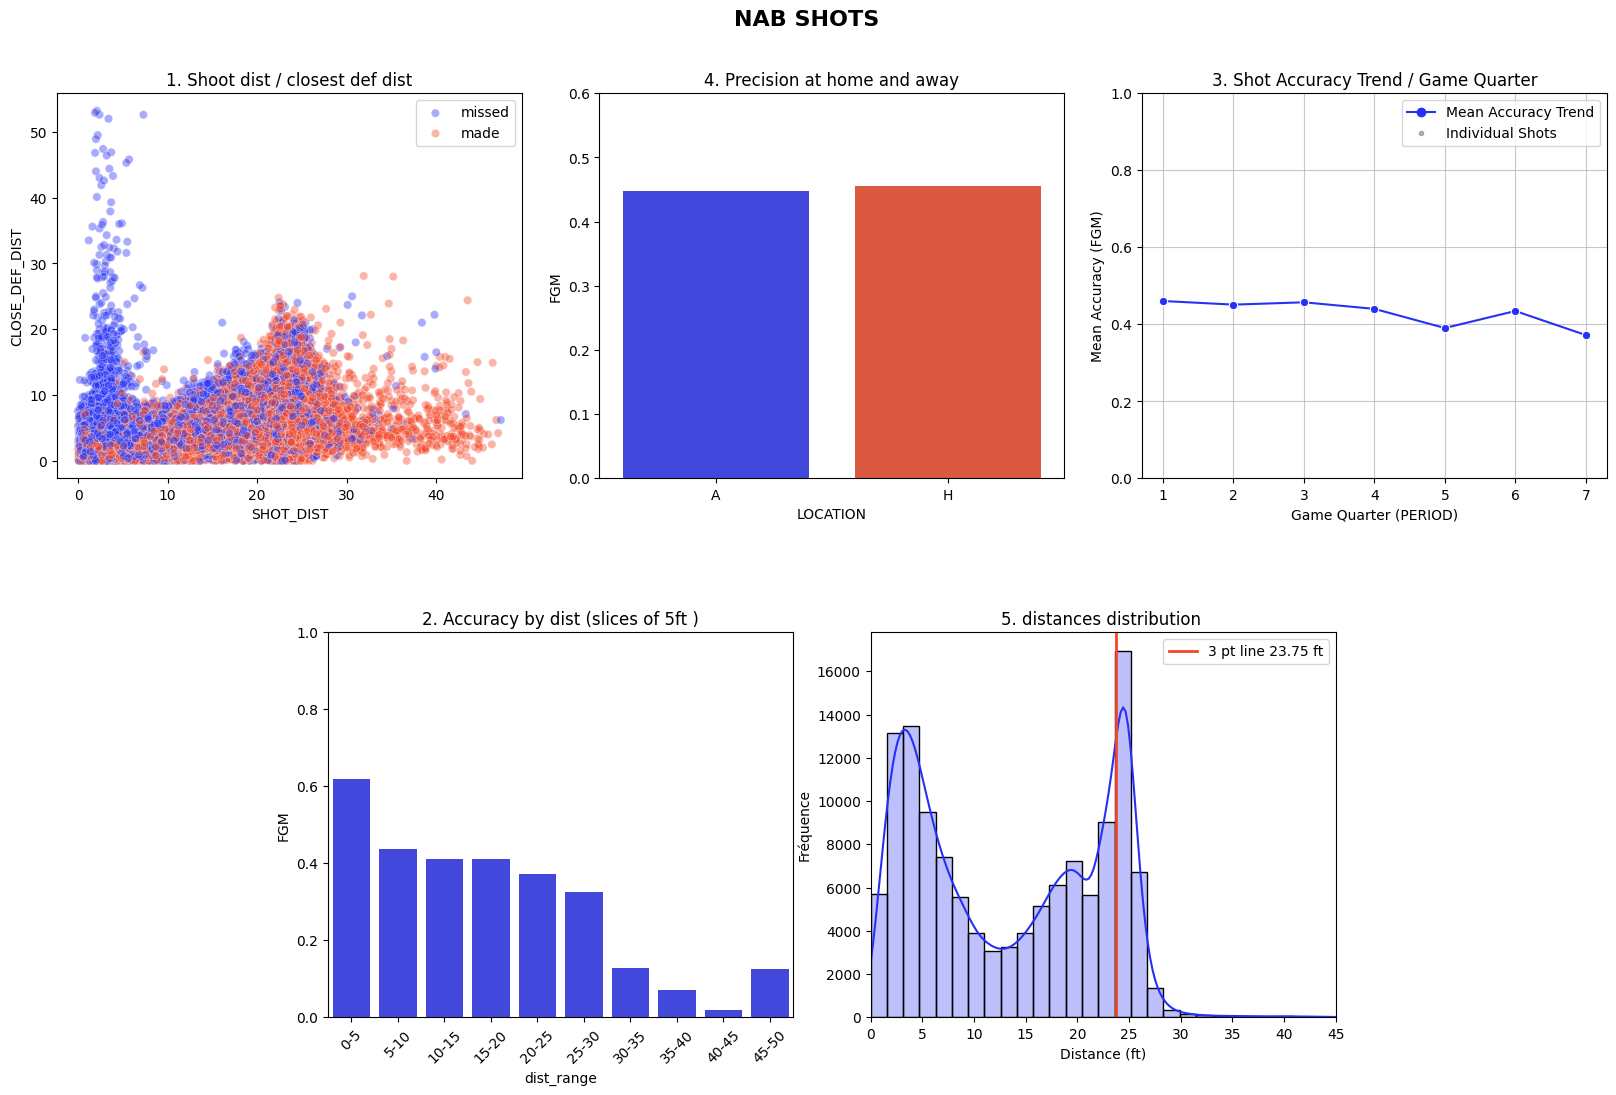

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_analysis = nba_shots.copy()
# Because FGM was deleted to prevent data leakage in case of a training i need to put it back on my data set
df_analysis["FGM"] = y

# color palette
c_blue = "#2731F5"
c_red = "#F54627"
status_colors = {0: c_red, 1: c_blue}

# if player name not found
target_col = "player_name" if "player_name" in nba_shots.columns else "PLAYER_NAME"

# Grid disposition
fig = plt.figure(figsize=(20, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# 1. AXE 1 : SHOT DISTANCE VS DEFENDER
ax1 = plt.subplot2grid(shape=(2, 6), loc=(0, 0), colspan=2)
sns.scatterplot(
    data=df_analysis,
    x="SHOT_DIST",
    y="CLOSE_DEF_DIST",
    hue="FGM",
    palette=status_colors,
    alpha=0.4,
    ax=ax1,
)
ax1.set_title("1. Shoot dist / closest def dist")
ax1.legend(labels=["missed", "made"])


# 2. AXE 2 : SHOOT ACCURACY BY DIST
ax2 = plt.subplot2grid((2, 6), (1, 1), colspan=2)

bins = list(range(0, int(df_analysis["SHOT_DIST"].max()) + 6, 5))
labels = [f"{i}-{i+5}" for i in bins[:-1]]
df_analysis["dist_range"] = pd.cut(
    df_analysis["SHOT_DIST"], bins=bins, labels=labels, right=False
)
acc_dist = df_analysis.groupby("dist_range", observed=True)["FGM"].mean().reset_index()

sns.barplot(data=acc_dist, x="dist_range", y="FGM", color=c_blue, ax=ax2)
ax2.set_title("2. Accuracy by dist (slices of 5ft )")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.set_ylim(0, 1)

# 3. AXE 3 : ACCURACY / GAME TIME
ax3 = plt.subplot2grid((2, 6), (0, 4), colspan=2)
accuracy_by_time = (
    df_analysis.groupby("PERIOD", observed=True)["FGM"].mean().reset_index()
)

sns.lineplot(
    data=accuracy_by_time, x="PERIOD", y="FGM", ax=ax3, color=c_blue, marker="o"
)
ax3.set_title("3. Shot Accuracy Trend / Game Quarter")
ax3.set_xlabel("Game Quarter (PERIOD)")
ax3.set_ylabel("Mean Accuracy (FGM)")
ax3.set_ylim(0, 1)
ax3.grid(True, linestyle="-", alpha=0.7)

trend_line = plt.Line2D([0], [0], color=c_blue, marker="o", label="Mean Accuracy Trend")
data_points = plt.Line2D(
    [0],
    [0],
    color="gray",
    marker=".",
    label="Individual Shots",
    linestyle="",
    alpha=0.6,
)
ax3.legend(handles=[trend_line, data_points], loc="upper right")

# 4. AXE 4 : IMPACT OF LOCATION ON PRECISION (placé avant AXE 2)
ax4 = plt.subplot2grid((2, 6), (0, 2), colspan=2)
acc_loc = df_analysis.groupby("LOCATION")["FGM"].mean().reset_index()

sns.barplot(
    data=acc_loc,
    x="LOCATION",
    y="FGM",
    hue="LOCATION",
    palette=[c_blue, c_red],
    ax=ax4,
    legend=False,
)
ax4.set_title("4. Precision at home and away")
ax4.set_ylim(0, 0.6)

# 5. DISTANCE DISTRIBUTION
ax5 = plt.subplot2grid((2, 6), (1, 3), colspan=2)
sns.histplot(
    df_analysis["SHOT_DIST"], bins=30, kde=True, color=c_blue, alpha=0.3, ax=ax5
)
ax5.axvline(
    x=23.75, color=c_red, linestyle="-", linewidth=2, label="3 pt line 23.75 ft"
)
ax5.set_title("5. distances distribution ")
ax5.set_xlabel("Distance (ft)")
ax5.set_ylabel("Fréquence")
ax5.set_xlim(0, 45)
ax5.legend()

plt.suptitle("NAB SHOTS", fontsize=16, fontweight="bold", y=0.95)
plt.show()